k0 = 250  →  f0 = 250.0 Hz  (250 ciclos en 1.0 s)
q = 0.2500 V   Pq = 0.005208 W   sigma_n = 0.072169 V


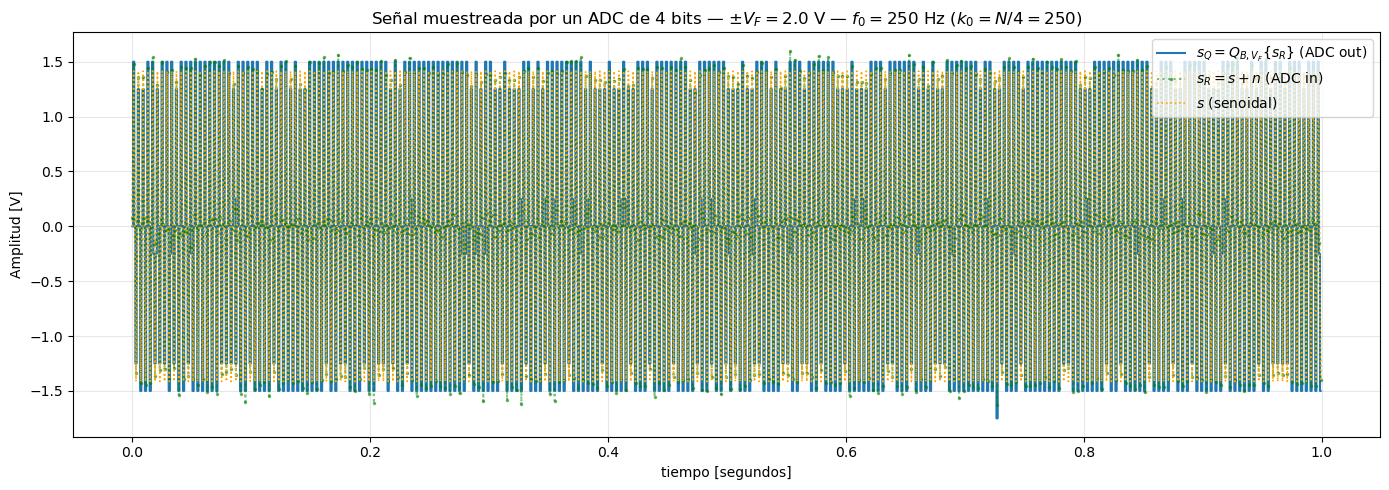

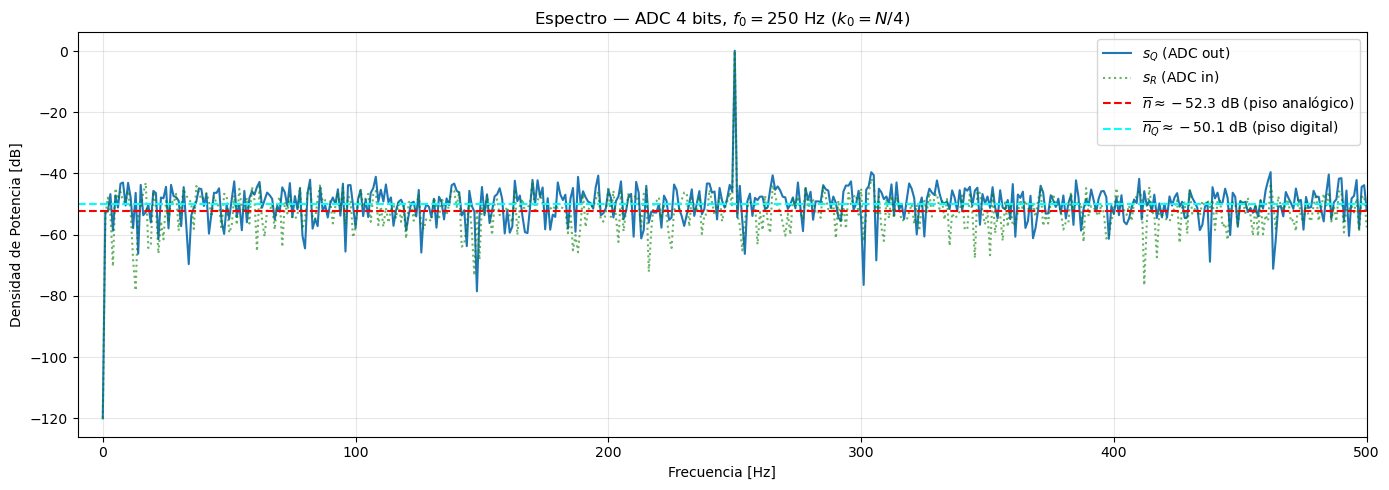

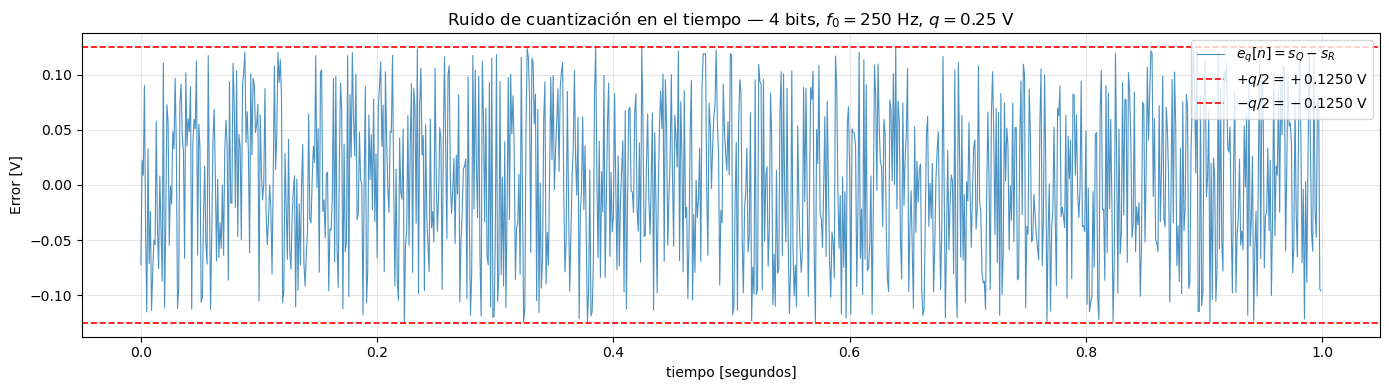

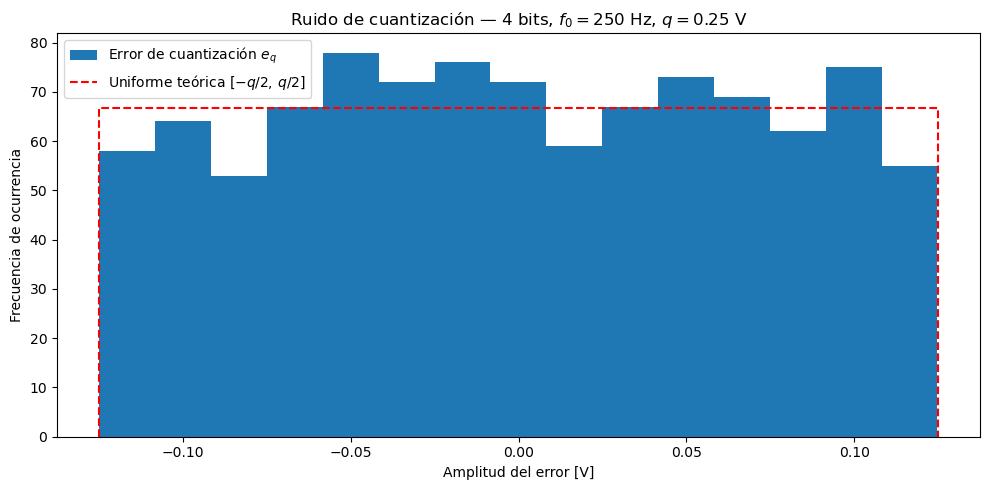

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# parametros
fs = 1000.0       # frec de muestreo
N  = 1000         # cant de muestras
k0 = N // 4       # k0 = 250 
f0 = k0 * fs / N  # 250 Hz
V_F = 2.0          # rango ADC
B = 4            # bits ADC
kn = 1.0          # factor de escala del ruido

q = (2 * V_F) / (2**B)   # paso de cuantizacion
Pq = q**2 / 12             # pot teorica ruido de cuantizacion
Pn = kn * Pq               # pot del ruido Gaussiano
sigma_n = np.sqrt(Pn)

# print(f"k0 = {k0}  →  f0 = {f0:.1f} Hz  ({k0} ciclos en {N/fs:.1f} s)")
# print(f"q = {q:.4f} V   Pq = {Pq:.6f} W   sigma_n = {sigma_n:.6f} V")

# Senales
t   = np.arange(N) / fs
s   = np.sqrt(2) * np.sin(2 * np.pi * f0 * t)          # energia normalizada unitaria
n   = np.random.normal(0, sigma_n, N)                   # ruido Gaussiano incorrelado
s_R = s + n                                             # entrada ADC
s_Q = np.clip(np.round(s_R / q) * q, -V_F, V_F - q)   # salida cuantizada
e_q = s_Q - s_R                                         # ruido de cuantizacion

# Senal en tiempo

plt.figure(figsize=(14, 5))
plt.step(t, s_Q, where='mid', lw=1.5,
         label=r'$s_Q = Q_{B,V_F}\{s_R\}$ (ADC out)')
plt.plot(t, s_R, '.:', color='green', markersize=3, alpha=0.5,
         label=r'$s_R = s + n$ (ADC in)')
plt.plot(t, s, ':', color='orange', lw=1.2,
         label='$s$ (senoidal)')
plt.title(f'Señal muestreada por un ADC de {B} bits — $\\pm V_F={V_F}$ V — '
          f'$f_0={f0:.0f}$ Hz ($k_0=N/4={k0}$)')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Espectro 

f_fft, Pxx_R = sig.periodogram(s_R, fs, window='boxcar', scaling='spectrum')
f_fft, Pxx_Q = sig.periodogram(s_Q, fs, window='boxcar', scaling='spectrum')

Pxx_R_dB = 10 * np.log10(Pxx_R + 1e-12)
Pxx_Q_dB = 10 * np.log10(Pxx_Q + 1e-12)

# Piso de ruido promedio

mask = np.ones(len(f_fft), dtype=bool)
mask[:2] = False
mask[k0 - 2 : k0 + 3] = False
piso_R_dB = np.mean(Pxx_R_dB[mask])
piso_Q_dB = np.mean(Pxx_Q_dB[mask])

plt.figure(figsize=(14, 5))
plt.plot(f_fft, Pxx_Q_dB, label=r'$s_Q$ (ADC out)', color='C0')
plt.plot(f_fft, Pxx_R_dB, label=r'$s_R$ (ADC in)', color='green', alpha=0.6, linestyle=':')
plt.axhline(piso_R_dB, color='red',  linestyle='--',
            label=f'$\\overline{{n}} \\approx {piso_R_dB:.1f}$ dB (piso analógico)')
plt.axhline(piso_Q_dB, color='cyan', linestyle='--',
            label=f'$\\overline{{n_Q}} \\approx {piso_Q_dB:.1f}$ dB (piso digital)')
plt.title(f'Espectro — ADC {B} bits, $f_0={f0:.0f}$ Hz ($k_0=N/4$)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(loc='upper right')
plt.xlim(-10, fs / 2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ruido de cuantizacion

plt.figure(figsize=(14, 4))
plt.plot(t, e_q, color='C0', lw=0.8, alpha=0.8, label=r'$e_q[n] = s_Q - s_R$')
plt.axhline( q/2, color='red', linestyle='--', lw=1.2, label=f'$+q/2 = +{q/2:.4f}$ V')
plt.axhline(-q/2, color='red', linestyle='--', lw=1.2, label=f'$-q/2 = -{q/2:.4f}$ V')
plt.title(f'Ruido de cuantización en el tiempo — {B} bits, $f_0={f0:.0f}$ Hz, $q={q}$ V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Error [V]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# histograma del ruido de cuantizacion

plt.figure(figsize=(10, 5))
plt.hist(e_q, bins=15, density=False, color='C0', label='Error de cuantización $e_q$')

altura_teorica = N / 15
plt.plot([-q/2, -q/2, q/2, q/2], [0, altura_teorica, altura_teorica, 0],
         'r--', lw=1.5, label=r'Uniforme teórica $[-q/2,\, q/2]$')

plt.title(f'Ruido de cuantización — {B} bits, $f_0={f0:.0f}$ Hz, $q={q}$ V')
plt.xlabel('Amplitud del error [V]')
plt.ylabel('Frecuencia de ocurrencia')
plt.legend()
plt.tight_layout()
plt.show()
